In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler

In [3]:
training_file = "training.csv"
test_file = "test.csv"

In [4]:
training_data = pd.read_csv(training_file)
test_data = pd.read_csv(test_file)

In [5]:
training_data

,age,sex,aki,creatinine_date_0,creatinine_result_0,creatinine_date_1,creatinine_result_1,creatinine_date_2,creatinine_result_2,creatinine_date_3,...,creatinine_date_39,creatinine_result_39,creatinine_date_40,creatinine_result_40,creatinine_date_41,creatinine_result_41,creatinine_date_42,creatinine_result_42,creatinine_date_43,creatinine_result_43
0,18,f,n,2024-01-01 07:54:00,102.56,2024-01-01 17:42:00,108.55,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,58,m,n,2024-01-01 10:39:00,125.00,2024-01-02 06:47:00,140.16,2024-01-02 07:10:00,145.98,2024-01-02 11:15:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,39,m,n,2024-01-01 14:26:00,187.44,2024-01-01 16:27:00,191.74,2024-01-09 10:46:00,197.47,2024-01-12 11:18:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,27,f,n,2024-01-01 16:05:00,141.85,2024-01-19 13:57:00,129.73,2024-09-21 05:57:00,132.16,2024-09-30 07:22:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,m,n,2024-01-01 16:17:00,72.29,2024-01-01 16:18:00,69.07,2024-01-05 10:54:00,72.91,2024-01-05 15:12:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7296,55,f,n,2025-03-31 15:10:00,151.55,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7297,43,f,n,2025-03-31 15:27:00,128.80,2025-03-31 17:27:00,132.97,2025-03-31 17:46:00,109.05,2025-03-31 23:32:00,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7298,26,f,n,2025-03-31 15:47:00,173.68,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7299,31,f,y,2025-03-31 16:36:00,76.50,2025-03-31 17:57:00,152.99,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


<Axes: >

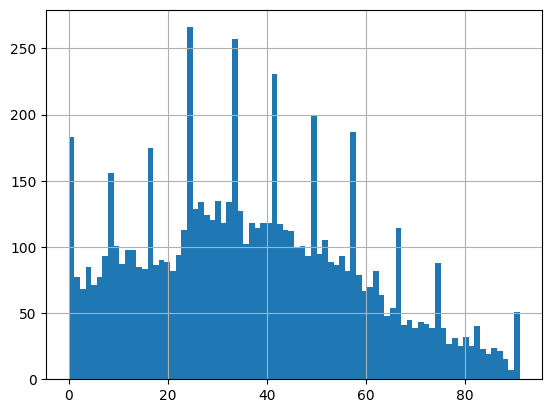

In [7]:
training_data["age"].hist(bins=80)

In [8]:
age_f_mask = training_data["sex"] == "f"
age_m_mask = training_data["sex"] == "m"

(len(training_data[age_f_mask]), len(training_data[age_m_mask]))

(3565, 3736)

In [9]:
aki_n_mask = training_data["aki"] == "n"
aki_y_mask = training_data["aki"] == "y"

(len(training_data[aki_n_mask]), len(training_data[aki_y_mask]))

(5785, 1516)

In [17]:
def collapse_columns(df, cols, new_col):
    cdf = df.copy()
    cdf[new_col] = cdf.apply(
        lambda row: [row[col] for col in cols if not pd.isna(row[col])], axis=1
    )
    cdf.drop(columns=cols, inplace=True)
    return cdf


creatinine_cols = [col for col in training_data.columns if "result" in col]
date_cols = [col for col in training_data.columns if "date" in col]

agg_training_data = collapse_columns(
    training_data, creatinine_cols, "creatinine_levels"
)
agg_training_data = collapse_columns(agg_training_data, date_cols, "dates")

agg_training_data

,age,sex,aki,creatinine_levels,dates
0,18,f,n,"[102.56, 108.55]","[2024-01-01 07:54:00, 2024-01-01 17:42:00]"
1,58,m,n,"[125.0, 140.16, 145.98, 130.16, 127.27, 104.46...","[2024-01-01 10:39:00, 2024-01-02 06:47:00, 202..."
2,39,m,n,"[187.44, 191.74, 197.47, 218.89, 220.71, 210.0...","[2024-01-01 14:26:00, 2024-01-01 16:27:00, 202..."
3,27,f,n,"[141.85, 129.73, 132.16, 138.93, 98.72, 114.38...","[2024-01-01 16:05:00, 2024-01-19 13:57:00, 202..."
4,4,m,n,"[72.29, 69.07, 72.91, 76.32, 73.24, 73.79, 59....","[2024-01-01 16:17:00, 2024-01-01 16:18:00, 202..."
...,...,...,...,...,...
7296,55,f,n,[151.55],[2025-03-31 15:10:00]
7297,43,f,n,"[128.8, 132.97, 109.05, 133.05]","[2025-03-31 15:27:00, 2025-03-31 17:27:00, 202..."
7298,26,f,n,[173.68],[2025-03-31 15:47:00]
7299,31,f,y,"[76.5, 152.99]","[2025-03-31 16:36:00, 2025-03-31 17:57:00]"


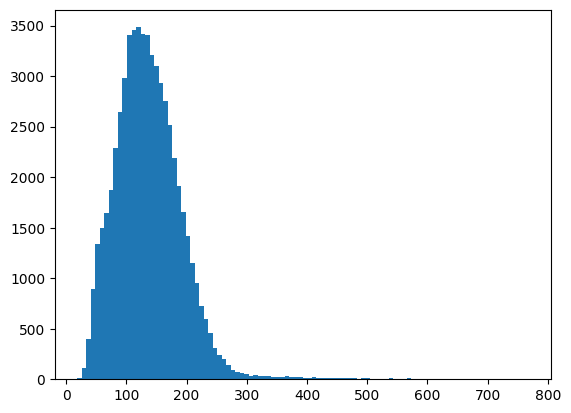

In [18]:
creatinine_levels = np.concat(agg_training_data["creatinine_levels"].tolist())

# Display histogram of creatinine levels
plt.hist(creatinine_levels, bins=100)
plt.show()

In [19]:
creatinine_levels = np.concat(agg_training_data["creatinine_levels"].tolist())
creatinine_normalizer = MinMaxScaler()
creatinine_normalizer.fit(creatinine_levels.reshape(-1, 1))

agg_training_data["creatinine_levels"] = agg_training_data["creatinine_levels"].apply(
    lambda x: creatinine_normalizer.transform(np.array(x).reshape(-1, 1)).reshape(-1)
)

agg_training_data

,age,sex,aki,creatinine_levels,dates
0,18,f,n,"[0.11207840414452427, 0.12007637460944803]","[2024-01-01 07:54:00, 2024-01-01 17:42:00]"
1,58,m,n,"[0.14204075092797822, 0.16228269287259325, 0.1...","[2024-01-01 10:39:00, 2024-01-02 06:47:00, 202..."
2,39,m,n,"[0.22541191550725026, 0.23115336342030074, 0.2...","[2024-01-01 14:26:00, 2024-01-01 16:27:00, 202..."
3,27,f,n,"[0.1645392154244666, 0.1483563436323337, 0.151...","[2024-01-01 16:05:00, 2024-01-19 13:57:00, 202..."
4,4,m,n,"[0.07166128127753893, 0.06736187144497556, 0.0...","[2024-01-01 16:17:00, 2024-01-01 16:18:00, 202..."
...,...,...,...,...,...
7296,55,f,n,[0.1774908537399525],[2025-03-31 15:10:00]
7297,43,f,n,"[0.14711458861858095, 0.15268245787379497, 0.1...","[2025-03-31 15:27:00, 2025-03-31 17:27:00, 202..."
7298,26,f,n,[0.20703928218548884],[2025-03-31 15:47:00]
7299,31,f,y,"[0.07728255935054877, 0.17941357118060194]","[2025-03-31 16:36:00, 2025-03-31 17:57:00]"


In [20]:
def get_time_diffs(dates):
    # Get the days between each date
    return [0] + [
        (dates[i] - dates[i - 1]).total_seconds() / 3600 for i in range(1, len(dates))
    ]


# Transform string dates to datetime objects
agg_training_data["dates"] = agg_training_data["dates"].apply(
    lambda x: [pd.to_datetime(date) for date in x]
)
agg_training_data["dates"] = agg_training_data["dates"].apply(get_time_diffs)

agg_training_data

,age,sex,aki,creatinine_levels,dates
0,18,f,n,"[0.11207840414452427, 0.12007637460944803]","[0, 9.8]"
1,58,m,n,"[0.14204075092797822, 0.16228269287259325, 0.1...","[0, 20.133333333333333, 0.38333333333333336, 4..."
2,39,m,n,"[0.22541191550725026, 0.23115336342030074, 0.2...","[0, 2.0166666666666666, 186.31666666666666, 72..."
3,27,f,n,"[0.1645392154244666, 0.1483563436323337, 0.151...","[0, 429.8666666666667, 5896.0, 217.41666666666..."
4,4,m,n,"[0.07166128127753893, 0.06736187144497556, 0.0...","[0, 0.016666666666666666, 90.6, 4.3, 51.383333..."
...,...,...,...,...,...
7296,55,f,n,[0.1774908537399525],[0]
7297,43,f,n,"[0.14711458861858095, 0.15268245787379497, 0.1...","[0, 2.0, 0.31666666666666665, 5.766666666666667]"
7298,26,f,n,[0.20703928218548884],[0]
7299,31,f,y,"[0.07728255935054877, 0.17941357118060194]","[0, 1.35]"


In [21]:
days_normalizer = MinMaxScaler()
days = np.concatenate(agg_training_data["dates"].tolist())
days_normalizer.fit(days.reshape(-1, 1))

agg_training_data["dates"] = agg_training_data["dates"].apply(
    lambda x: days_normalizer.transform(np.array(x).reshape(-1, 1)).reshape(-1)
)

agg_training_data

,age,sex,aki,creatinine_levels,dates
0,18,f,n,"[0.11207840414452427, 0.12007637460944803]","[0.0, 0.0009326464318343316]"
1,58,m,n,"[0.14204075092797822, 0.16228269287259325, 0.1...","[0.0, 0.0019160491320678102, 3.648106791188712..."
2,39,m,n,"[0.22541191550725026, 0.23115336342030074, 0.2...","[0.0, 0.0001919221398842757, 0.017731385138564..."
3,27,f,n,"[0.1645392154244666, 0.1483563436323337, 0.151...","[0.0, 0.04090955232971272, 0.5611105471525734,..."
4,4,m,n,"[0.07166128127753893, 0.06736187144497556, 0.0...","[0.0, 1.586133387473353e-06, 0.008622221094305..."
...,...,...,...,...,...
7296,55,f,n,[0.1774908537399525],[0.0]
7297,43,f,n,"[0.14711458861858095, 0.15268245787379497, 0.1...","[0.0, 0.00019033600649680235, 3.01365343619937..."
7298,26,f,n,[0.20703928218548884],[0.0]
7299,31,f,y,"[0.07728255935054877, 0.17941357118060194]","[0.0, 0.0001284768043853416]"


In [32]:
age_normalizer = MinMaxScaler()

ages = agg_training_data["age"].tolist()
age_normalizer.fit(np.array(ages).reshape(-1, 1))

agg_training_data["age"] = age_normalizer.transform(np.array(ages).reshape(-1, 1))

agg_training_data

,age,sex,aki,creatinine_levels,dates
0,0.197802,f,n,"[0.11207840414452427, 0.12007637460944803]","[0.0, 0.0009326464318343316]"
1,0.637363,m,n,"[0.14204075092797822, 0.16228269287259325, 0.1...","[0.0, 0.0019160491320678102, 3.648106791188712..."
2,0.428571,m,n,"[0.22541191550725026, 0.23115336342030074, 0.2...","[0.0, 0.0001919221398842757, 0.017731385138564..."
3,0.296703,f,n,"[0.1645392154244666, 0.1483563436323337, 0.151...","[0.0, 0.04090955232971272, 0.5611105471525734,..."
4,0.043956,m,n,"[0.07166128127753893, 0.06736187144497556, 0.0...","[0.0, 1.586133387473353e-06, 0.008622221094305..."
...,...,...,...,...,...
7296,0.604396,f,n,[0.1774908537399525],[0.0]
7297,0.472527,f,n,"[0.14711458861858095, 0.15268245787379497, 0.1...","[0.0, 0.00019033600649680235, 3.01365343619937..."
7298,0.285714,f,n,[0.20703928218548884],[0.0]
7299,0.340659,f,y,"[0.07728255935054877, 0.17941357118060194]","[0.0, 0.0001284768043853416]"


In [31]:
labels = (agg_training_data["aki"] == "y").astype(int).tolist()
labels

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 1,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 1,
 0,
 0,
 0,
 1,
 0,
 0,
 1,
 0,


In [140]:
import pandas as pd
import numpy as np
import torch

from torch.utils.data import Dataset
from sklearn.preprocessing import MinMaxScaler


def collapse_columns(df, cols, new_col):
    cdf = df.copy()
    cdf[new_col] = cdf.apply(
        lambda row: [row[col] for col in cols if not pd.isna(row[col])], axis=1
    )
    cdf.drop(columns=cols, inplace=True)
    return cdf


def get_time_diff(dates, time_unit="days"):
    result = np.array(
        [0] + [(dates[i] - dates[i - 1]).total_seconds() for i in range(1, len(dates))]
    )
    if time_unit == "seconds":
        return result
    elif time_unit == "hours":
        return result / 3600
    elif time_unit == "days":
        return result / 86400


class AKIDataset(Dataset):
    def __init__(self, file_name):
        # Load data
        self._df = pd.read_csv(file_name)

        # Drop unused columns
        self._df.drop(columns=["sex"], inplace=True)

        # Collapse time series into a single column
        level_cols = [col for col in self._df.columns if "result" in col]
        date_cols = [col for col in self._df.columns if "date" in col]

        self._df = collapse_columns(self._df, level_cols, "creatinine")
        self._df = collapse_columns(self._df, date_cols, "dates")

        # Map dates to intervals between measurements
        self._df["dates"] = self._df["dates"].apply(
            lambda x: [pd.to_datetime(d) for d in x]
        )
        self._df["dates"] = self._df["dates"].apply(
            lambda x: get_time_diff(x, time_unit="days")
        )

        self._normalize()

        self.age = torch.tensor(self._df["age"].tolist(), dtype=torch.float32).reshape(
            -1, 1
        )
        self.levels = [
            torch.tensor(x, dtype=torch.float32)
            for x in self._df["creatinine"].tolist()
        ]
        self.dates = [
            torch.tensor(x, dtype=torch.float32) for x in self._df["dates"].tolist()
        ]

        self.y = torch.tensor(
            (self._df["aki"] == "y").astype(int).tolist(), dtype=torch.int64
        ).reshape(-1, 1)

    def _normalize(self):
        # Normalize levels
        self.level_normalizer = MinMaxScaler()

        levels = np.concatenate(self._df["creatinine"].tolist())
        self.level_normalizer.fit(levels.reshape(-1, 1))

        self._df["creatinine"] = self._df["creatinine"].apply(
            lambda x: self.level_normalizer.transform(
                np.array(x).reshape(-1, 1)
            ).reshape(-1)
        )

        # Normalize dates
        self.date_normalizer = MinMaxScaler()

        dates = np.concatenate(self._df["dates"].tolist())
        self.date_normalizer.fit(dates.reshape(-1, 1))

        self._df["dates"] = self._df["dates"].apply(
            lambda x: self.date_normalizer.transform(
                np.array(x).reshape(-1, 1)
            ).reshape(-1)
        )

        # Normalize age
        self.age_normalizer = MinMaxScaler()

        ages = self._df["age"].tolist()
        self.age_normalizer.fit(np.array(ages).reshape(-1, 1))

        self._df["age"] = self.age_normalizer.transform(
            np.array(ages).reshape(-1, 1)
        ).reshape(-1)

    def __getitem__(self, idx):
        return (
            self.age[idx],
            torch.stack([self.levels[idx], self.dates[idx]], dim=-1),
            self.y[idx],
        )

    def __len__(self):
        return len(self._df)

In [141]:
ds = AKIDataset("training.csv")

In [142]:
ds[0]

(tensor([0.1978]),
 tensor([[0.1121, 0.0000],
         [0.1201, 0.0009]]),
 tensor([0]))

In [81]:
from torch.nn.utils.rnn import pack_padded_sequence, pad_sequence


def collate_fn(batch):
    ages, levels, y = zip(*batch)

    # Compute lengths
    lengths = torch.tensor([len(x) for x in levels])

    # Sort by length
    indices = torch.argsort(lengths, descending=True)
    lengths = lengths[indices]
    ages = torch.stack(ages)[indices]
    levels = [levels[i] for i in indices]
    y = torch.stack(y)[indices]

    # Pad sequences
    levels = pad_sequence(levels, batch_first=True)

    # Pack padded sequences
    levels = pack_padded_sequence(
        levels, lengths, batch_first=True, enforce_sorted=False
    )

    return ages, levels, y

In [143]:
from torch.utils.data import DataLoader

dl = DataLoader(ds, batch_size=32, shuffle=True, collate_fn=collate_fn)

for batch in dl:
    ages, levels, y = batch
    print(ages.shape, levels.data.shape, y.shape)
    break

torch.Size([32, 1]) torch.Size([257, 2]) torch.Size([32, 1])


In [175]:
class AKIModel(torch.nn.Module):
    def __init__(self, lstm_hidden_size=64, lstm_num_layers=2, fc_hidden_size=32):
        super(AKIModel, self).__init__()

        self.lstm = torch.nn.LSTM(
            input_size=2,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            batch_first=True,
        )

        self.fc = torch.nn.Linear(lstm_hidden_size + 1, fc_hidden_size)
        self.output = torch.nn.Linear(fc_hidden_size, 1)

    def forward(self, levels, age):
        _, (h, _) = self.lstm(levels)
        h = h[-1]
        h = torch.cat([h, age], dim=-1)
        h = torch.relu(self.fc(h))
        h = self.output(h)
        return h

In [177]:
from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score


def train(
    model,
    train_dataset,
    val_dataset,
    num_epochs=10,
    batch_size=32,
    lr=1e-3,
    checkpoint_dir="checkpoints",
    early_stopping_patience=3,
    save_best=True,
):
    # Device setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)

    # Class weights for imbalanced dataset (labels are [batch, 1])
    train_y = train_dataset.y.squeeze().numpy()
    num_pos = np.sum(train_y)
    num_neg = len(train_y) - num_pos
    pos_weight = num_neg / num_pos

    # Loss function
    criterion = torch.nn.BCEWithLogitsLoss(
        pos_weight=torch.tensor(pos_weight).to(device)
    )
    # Optimizer
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    # Data loaders
    train_dl = DataLoader(
        train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn
    )
    val_dl = DataLoader(val_dataset, batch_size=batch_size, collate_fn=collate_fn)

    # Training loop
    best_val_loss = np.inf
    best_epoch = 0

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0
        train_y_true, train_y_pred = [], []

        train_pbar = tqdm(
            train_dl, desc=f"Epoch {epoch + 1}/{num_epochs}", unit="batch"
        )
        for batch in train_pbar:
            age, levels, y = [x.to(device) for x in batch]

            optimizer.zero_grad()

            output = model(levels, age)
            loss = criterion(output, y.float())
            loss.backward()
            optimizer.step()

            train_loss += loss.item()
            preds = (torch.sigmoid(output) > 0.5).int()
            train_y_true.extend(y.tolist())
            train_y_pred.extend(preds.tolist())

        train_loss /= len(train_dl)
        train_pbar.set_postfix(train_loss=train_loss)
        print(f"Epoch {epoch + 1}/{num_epochs}: Train Loss = {train_loss:.4f}")

        model.eval()
        val_loss = 0.0
        val_y_true, val_y_pred = [], []

        for batch in val_dl:
            age, levels, y = [x.to(device) for x in batch]

            output = model(levels, age)
            loss = criterion(output, y.float())

            val_loss += loss.item()
            preds = (torch.sigmoid(output) > 0.5).int()
            val_y_true.extend(y.tolist())
            val_y_pred.extend(preds.tolist())

        val_loss /= len(val_dl)
        print(
            f"Epoch {epoch + 1}/{num_epochs}: Train Loss = {train_loss:.4f}, Val Loss = {val_loss:.4f}"
        )

        # Calculate f3 score
        precision = precision_score(val_y_true, val_y_pred, zero_division=0)
        recall = recall_score(val_y_true, val_y_pred, zero_division=0)
        f3 = (1 + 3**2) * (precision * recall) / (3**2 * precision + recall + 1e-8)

        print(
            f"Epoch {epoch + 1}/{num_epochs}: Precision = {precision:.4f}, Recall = {recall:.4f}, F3 = {f3:.4f}"
        )

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch

            if save_best:
                torch.save(model.state_dict(), f"{checkpoint_dir}/best_model.pth")
                print("Saved best model")

        if epoch - best_epoch >= early_stopping_patience:
            print(f"Stopping early at epoch {epoch + 1}")
            break

        if not save_best:
            torch.save(model.state_dict(), f"{checkpoint_dir}/epoch_{epoch + 1}.pth")
            print(f"Saved model checkpoint at epoch {epoch + 1}")

    print("Training complete")

In [144]:
train_ds = AKIDataset("training.csv")
val_ds = AKIDataset("test.csv")

In [178]:
model = AKIModel()

In [180]:
train(
    model,
    train_ds,
    val_ds,
    num_epochs=10,
    batch_size=32,
    lr=1e-3,
    checkpoint_dir="checkpoints",
    early_stopping_patience=3,
    save_best=True,
)

Epoch 1/10: 100%|██████████| 229/229 [00:05<00:00, 43.05batch/s]


Epoch 1/10: Train Loss = 0.3634
Epoch 1/10: Train Loss = 0.3634, Val Loss = 0.1621
Epoch 1/10: Precision = 0.9047, Recall = 0.9655, F3 = 0.9590
Saved best model


Epoch 2/10: 100%|██████████| 229/229 [00:05<00:00, 44.81batch/s]


Epoch 2/10: Train Loss = 0.1201
Epoch 2/10: Train Loss = 0.1201, Val Loss = 0.1052
Epoch 2/10: Precision = 0.9197, Recall = 0.9738, F3 = 0.9681
Saved best model


Epoch 3/10: 100%|██████████| 229/229 [00:04<00:00, 47.79batch/s]


...

Epoch 8/10: Train Loss = 0.0349
Epoch 8/10: Train Loss = 0.0349, Val Loss = 0.0367
Epoch 8/10: Precision = 0.9828, Recall = 0.9872, F3 = 0.9868
Saved best model


Epoch 9/10: 100%|██████████| 229/229 [00:04<00:00, 48.06batch/s]


Epoch 9/10: Train Loss = 0.0381
Epoch 9/10: Train Loss = 0.0381, Val Loss = 0.0296
Epoch 9/10: Precision = 0.9917, Recall = 0.9910, F3 = 0.9911
Saved best model


Epoch 10/10: 100%|██████████| 229/229 [00:05<00:00, 44.85batch/s]


Epoch 10/10: Train Loss = 0.0258
Epoch 10/10: Train Loss = 0.0258, Val Loss = 0.0264
Epoch 10/10: Precision = 0.9738, Recall = 0.9968, F3 = 0.9945
Saved best model
Training complete


In [181]:
model.load_state_dict(torch.load("checkpoints/best_model.pth"))

C:\Users\andre\AppData\Local\Temp\ipykernel_10468\3184540350.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("checkpoints/best_model.pth

<All keys matched successfully>

In [182]:
def evaluate(model, dataset):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    dl = DataLoader(dataset, batch_size=32, collate_fn=collate_fn)

    y_true, y_pred = [], []

    for batch in dl:
        age, levels, y = [x.to(device) for x in batch]

        output = model(levels, age)
        preds = (torch.sigmoid(output) > 0.5).int()

        y_true.extend(y.tolist())
        y_pred.extend(preds.tolist())

    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f3 = (1 + 3**2) * (precision * recall) / (3**2 * precision + recall + 1e-8)

    print(f"Precision = {precision:.4f}, Recall = {recall:.4f}, F3 = {f3:.4f}")

In [183]:
evaluate(model, val_ds)

Precision = 0.9738, Recall = 0.9968, F3 = 0.9945


In [ ]:
def infer(model, dataset):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    model.eval()

    dl = DataLoader(dataset, batch_size=32, collate_fn=collate_fn)

    y_pred = []

    for batch in dl:
        age, levels, y = [x.to(device) for x in batch]

        output = model(levels, age)
        preds = (torch.sigmoid(output) > 0.5).int()

        y_pred.extend(preds.tolist())

    return y_pred